In [1]:
import os
import base64
from IPython.display import HTML

video_file_path = 'Spacejam/dataset/examples/0000000_flipped.mp4'


try:
    with open(video_file_path, "rb") as video_file:
        video_bytes = video_file.read()
    video_b64 = base64.b64encode(video_bytes).decode()
    video_tag = f'<video width="640" height="480" controls><source src="data:video/mp4;base64,{video_b64}" type="video/mp4"></video>'
    display(HTML(video_tag))

except FileNotFoundError:
    print(f"Error: Video file not found at {video_file_path}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [2]:
#get labels

with open('SpaceJam/dataset/labels_dict.json', 'r') as g:
    labels_wrong = g.read()

data = eval(labels_wrong)

labels = {str(key): i for key, i in data.items()} #converting keys to string rather than integer

labels

{'0': 'block',
 '1': 'pass',
 '2': 'run',
 '3': 'dribble',
 '4': 'shoot',
 '5': 'ball in hand',
 '6': 'defense',
 '7': 'pick',
 '8': 'no_action',
 '9': 'walk',
 '10': 'discard'}

In [3]:
import json

with open('SpaceJam/dataset/annotation_dict.json', 'r') as f:
    annotations = json.load(f)

annotations

{'0014297': 9,
 '0024339': 8,
 '0007545': 9,
 '0021609': 9,
 '0016126': 9,
 '0008080': 9,
 '0006103_flipped': 0,
 '0015195': 9,
 '0015015': 3,
 '0016240': 8,
 '0036279': 8,
 '0013083': 6,
 '0012589': 2,
 '0024942': 9,
 '0003812': 3,
 '0000417': 2,
 '0002127': 2,
 '0027751': 2,
 '0009777': 9,
 '0027376': 8,
 '0009722': 2,
 '0006374_flipped': 7,
 '0027741': 2,
 '0034771': 8,
 '0014021': 9,
 '0018453': 6,
 '0009254': 6,
 '0023268': 2,
 '0002939': 2,
 '0016195': 6,
 '0019076_flipped': 3,
 '0026722': 9,
 '0006616': 9,
 '0034041': 6,
 '0003290_flipped': 7,
 '0025974': 2,
 '0020817': 6,
 '0018514': 8,
 '0011164': 9,
 '0016411': 6,
 '0018290': 5,
 '0000663': 9,
 '0004986': 9,
 '0014011': 5,
 '0015217': 0,
 '0026903': 9,
 '0008101_flipped': 7,
 '0004772': 7,
 '0014341': 9,
 '0000307': 2,
 '0022786': 9,
 '0018407': 6,
 '0035846': 9,
 '0009845_flipped': 3,
 '0019064': 9,
 '0004906': 8,
 '0024670': 9,
 '0025687': 9,
 '0020925': 9,
 '0018588': 9,
 '0011739': 8,
 '0001927': 9,
 '0000026': 7,
 '00149

In [4]:
import pandas as pd

action_video_path = 'Spacejam/dataset/examples/'

#dataframe of names and labels
har_frame = []
for video_name, label in annotations.items():
    video_path = os.path.join(action_video_path, f"{video_name}.mp4") #video clips
    if os.path.exists(video_path): #check file exists
        har_frame.append({"video_path": video_path, "label": label})

har_frame = pd.DataFrame(har_frame)

print("Sample DataFrame:")
print(har_frame.head())

Sample DataFrame:
                              video_path  label
0  Spacejam/dataset/examples/0014297.mp4      9
1  Spacejam/dataset/examples/0024339.mp4      8
2  Spacejam/dataset/examples/0007545.mp4      9
3  Spacejam/dataset/examples/0021609.mp4      9
4  Spacejam/dataset/examples/0016126.mp4      9


In [5]:
print(har_frame.shape)
print(har_frame['label'].value_counts())

(37085, 2)
label
9    11749
8     6490
2     5924
6     3866
3     3490
5     2362
1     1070
0      996
7      712
4      426
Name: count, dtype: int64


In [18]:
%pip install -U matplotlib

  Using cached matplotlib-3.10.1-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.1-cp311-cp311-win_amd64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.10.1-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.1-cp311-cp311-win_amd64.whl (219 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\dinod\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\backends\\backend_gtk3.py'
Check the permissions.


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\dinod\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


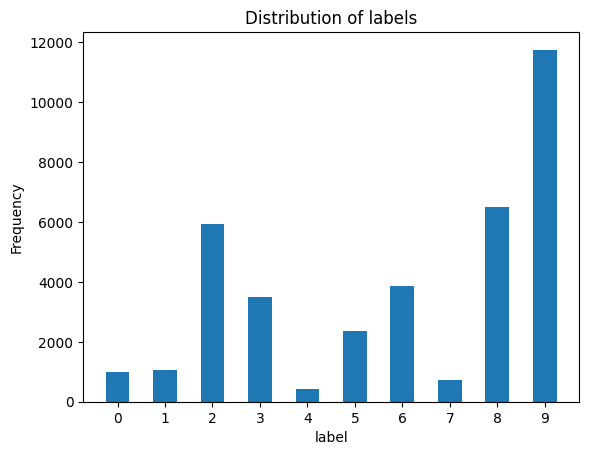

In [6]:
import matplotlib.pyplot as plt
import numpy as np


labels, counts = np.unique(har_frame['label'], return_counts=True)

plt.bar(labels, counts, width=0.5, align='center')

plt.xticks(labels)

plt.xlabel('label')
plt.ylabel('Frequency')
plt.title('Distribution of labels')

plt.show()

Attempt as kinetics rd+1

In [23]:
%pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\dinod\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [47]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.6.0%2Bcu118-cp311-cp311-win_amd64.whl.metadata (28 kB)
  Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.6.0%2Bcu118-cp311-cp311-win_amd64.whl.metadata (6.8 kB)
Using cached https://download.pytorch.org/whl/cu118/torch-2.6.0%2Bcu118-cp311-cp311-win_amd64.whl (2728.9 MB)
Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.6.0%2Bcu118-cp311-cp311-win_amd64.whl (4.1 MB)



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\dinod\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import torch
import torchmetrics
from torchmetrics import Accuracy, Precision
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights
from torch.utils.data import Dataset, DataLoader

In [ ]:
import random

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=16, transform=None):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.transform = transform

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        frames = extract_frames(video_path, self.num_frames)
        frames = torch.from_numpy(frames) #for torch

        if self.transform:
            frames = self.transform(frames)

        return frames, label

    def augment_frames(self, frames):
        augmented_frames = []
        for frame in frames: #augment every frame in video
            frame = frame.numpy().transpose(1, 2, 0)  # Convert to HWC
            frame = cv2.resize(frame, (128, 128)) 

            if random.random() < 0.5:  #cropping with 50% probability
                x = random.randint(0, 128 - 112) #crop location
                y = random.randint(0, 128 - 112)
                frame = frame[y:y + 112, x:x + 112]  #random Crop 112x112
            else: #if not crop return to normal size
                frame = cv2.resize(frame, (112, 112))

            #Randomly flip the frame horizontally
            if random.random() < 0.5:
                frame = cv2.flip(frame, 1)

            frame = frame.transpose(2, 0, 1) #back to CHW
            augmented_frames.append(torch.from_numpy(frame))

        return torch.stack(augmented_frames) # Stack back into a tensor

In [ ]:
def extract_frames(video_path, num_frames=16):
    #open video file
    cap = cv2.VideoCapture(video_path)
    frames = []

    #no of frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    #interval to expect frames
    frame_interval = max(total_frames // num_frames, 1)

    #loop through and extract frames
    for i in range(num_frames):
    
        #read current frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * frame_interval)
        ret, frame = cap.read()

        #break if video ends
        if not ret:
            break

        frame = cv2.resize(frame, (112, 112))

        #add frame to frame list
        frames.append(frame)

    #close
    cap.release()

    #fill missing frames with blank frames
    while len(frames) < num_frames:
        frames.append(np.zeros((112, 112, 3), np.uint8))

    #convert to numpy
    return np.array(frames).transpose((0, 3, 1, 2)) #for tchw

In [10]:
weights = R2Plus1D_18_Weights.DEFAULT
preprocess = weights.transforms()
pretrained_model = r2plus1d_18(weights=weights)

In [38]:
%pip install scikit-learn

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     -------------------------------------- 60.8/60.8 kB 802.0 kB/s eta 0:00:00
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB 5.2 MB/s eta 0:00:03
   -- ------------------------------------- 0.7/11.1 MB 7.3 MB/s eta 0:00:02
   ---- ----------------------------------- 1.1/11.1 MB 8.0 MB/s eta 0:00:02
   ----- ---------------------------------- 1.6/11.1 MB 8.4 MB/s eta 0:00:02
   ------- -------------------------------- 2.0/11.1 MB 9.1 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/11.1 MB 9.1 MB/s eta 0:00:01
   ---------- ----------------------------- 2.9/11.1 MB 9.2 MB/s eta 0:00:01
   ----------- ---------------------------- 3.3/11.1 MB 9.2 MB/s eta 0:00:01
   ------------- -------------------------- 3.7/11.1 MB 9.2 MB/s eta 0:00:01
   ---------


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\dinod\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
#import sklearn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

batch_size = 8

video_paths = har_frame["video_path"].tolist()
labels = har_frame["label"].tolist()

#dataset splits
video_paths_train, video_paths_val, labels_train, labels_val = train_test_split(
    video_paths, labels, test_size=0.2, random_state=42
)

train_dataset = VideoDataset(video_paths_train, labels_train, transform=preprocess)
val_dataset = VideoDataset(video_paths_val, labels_val, transform=preprocess)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [12]:
import torch
print(torch.cuda.is_available())

True


In [13]:
accuracy = Accuracy(task="multiclass", num_classes=10).to('cuda')
precision = Precision(task="multiclass", num_classes=10).to('cuda')

#remove last few layers
pretrained_model.fc = torch.nn.Identity()

for param in pretrained_model.parameters(): #unfreeze
    param.requires_grad = True

num_classes = 10

classification_head = torch.nn.Sequential(
        torch.nn.Linear(512, 256),
        torch.nn.ReLU(),
        torch.nn.Dropout(0.5),
        torch.nn.Linear(256, num_classes),
    )

model = torch.nn.Sequential(
    pretrained_model,
    classification_head
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.CrossEntropyLoss()

# Training loop
num_epochs = 25
#batch_size = 128
model = model.to('cuda')

In [17]:
%pip install opencv-python-headless

   ---------------------------------------- 0.0/39.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.4 MB 320.0 kB/s eta 0:02:04
   ---------------------------------------- 0.1/39.4 MB 1.2 MB/s eta 0:00:34
    --------------------------------------- 0.5/39.4 MB 4.1 MB/s eta 0:00:10
    --------------------------------------- 1.0/39.4 MB 5.5 MB/s eta 0:00:08
   - -------------------------------------- 1.4/39.4 MB 6.7 MB/s eta 0:00:06
   - -------------------------------------- 1.8/39.4 MB 6.8 MB/s eta 0:00:06
   -- ------------------------------------- 2.3/39.4 MB 7.2 MB/s eta 0:00:06
   -- ------------------------------------- 2.7/39.4 MB 7.5 MB/s eta 0:00:05
   --- ------------------------------------ 3.1/39.4 MB 7.7 MB/s eta 0:00:05
   --- ------------------------------------ 3.6/39.4 MB 8.1 MB/s eta 0:00:05
   ---- ----------------------------------- 4.0/39.4 MB 8.2 MB/s eta 0:00:05
   ---- ----------------------------------- 4.4/39.4 MB 8.3 MB/s eta 0:00:05
   -


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\dinod\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
import cv2

In [15]:
torch.cuda.empty_cache()

In [ ]:
scaler = torch.cuda.amp.GradScaler()

for epoch in range(num_epochs):
    accuracy.reset()
    precision.reset()
    
    for i, (batch_X, batch_y) in enumerate(train_loader):
        batch_X = batch_X.to('cuda')
        batch_y = batch_y.to('cuda')

        optimizer.zero_grad()

        #mixed precision
        with torch.cuda.amp.autocast():
            outputs = model(batch_X)
            loss = loss_fn(outputs, batch_y)

        #scale loss before backward
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        accuracy.update(outputs, batch_y)
        precision.update(outputs, batch_y)

        if i % 10 == 0:  #print every 10 batches
            print(f"Batch {i + 1}/{len(train_loader)}, "
                  f"Loss: {loss.item():.4f}, "
                  f"Accuracy: {accuracy.compute().item():.4f}, "
                  f"Precision: {precision.compute().item():.4f}")

    #final metrics for epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, "
          f"Accuracy: {accuracy.compute().item():.4f}, "
          f"Precision: {precision.compute().item():.4f})")

    torch.cuda.empty_cache()

C:\Users\dinod\AppData\Local\Temp\ipykernel_17512\3775194497.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Add this at the start
C:\Users\dinod\AppData\Local\Temp\ipykernel_17512\3775194497.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Batch 1/3709, Loss: 2.6665, Accuracy: 0.0000, Precision: 0.0000
Batch 11/3709, Loss: 2.0261, Accuracy: 0.1591, Precision: 0.1591
Batch 21/3709, Loss: 2.2360, Accuracy: 0.1786, Precision: 0.1786
Batch 31/3709, Loss: 2.0203, Accuracy: 0.2218, Precision: 0.2218
Batch 41/3709, Loss: 2.3302, Accuracy: 0.2470, Precision: 0.2470
Batch 51/3709, Loss: 1.8005, Accuracy: 0.2623, Precision: 0.2623
Batch 61/3709, Loss: 1.6030, Accuracy: 0.2746, Precision: 0.2746
Batch 71/3709, Loss: 2.0730, Accuracy: 0.2958, Precision: 0.2958
Batch 81/3709, Loss: 2.2415, Accuracy: 0.2948, Precision: 0.2948
Batch 91/3709, Loss: 1.5679, Accuracy: 0.2967, Precision: 0.2967
Batch 101/3709, Loss: 1.9794, Accuracy: 0.3057, Precision: 0.3057
Batch 111/3709, Loss: 2.2814, Accuracy: 0.3097, Precision: 0.3097
Batch 121/3709, Loss: 1.5734, Accuracy: 0.3110, Precision: 0.3110
Batch 131/3709, Loss: 1.3126, Accuracy: 0.3149, Precision: 0.3149
Batch 141/3709, Loss: 1.4186, Accuracy: 0.3200, Precision: 0.3200
Batch 151/3709, Loss:

In [17]:
#calculate overall scores on the validation set
model.eval() 
accuracy.reset()
precision.reset()


with torch.no_grad():  #disable gradient
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to('cuda')
        batch_y = batch_y.to('cuda')

        
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        
        accuracy.update(preds, batch_y)
        precision.update(preds, batch_y)

#overall scores
overall_precision = accuracy.compute()
overall_accuracy = accuracy.compute()
print(f"Overall Accuracy: {overall_accuracy.item():.4f}, Overall Precision: {overall_precision}")

Overall Accuracy: 0.7401, Overall Precision: 0.7400566339492798


In [22]:
torch.save(model.state_dict(), "model")

